## LAB EXERCISE - 1 - IMDB MOVIE REVIEWS


In [3]:
# Various NLP preprocessing tasks
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import string
import re
import spacy

from bs4 import BeautifulSoup
from wordcloud import WordCloud, STOPWORDS

from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk import pos_tag
from nltk.wsd import lesk
from nltk.chunk import ne_chunk
from nltk.tree import Tree


# Download required NLTK resources
nltk.download('all')

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to
[nltk_data]    |     /Users/bryanlim/nltk_data...
[nltk_data]    |   Package abc is already up-to-date!
[nltk_data]    | Downloading package alpino to
[nltk_data]    |     /Users/bryanlim/nltk_data...
[nltk_data]    |   Package alpino is already up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /Users/bryanlim/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger is already up-
[nltk_data]    |       to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /Users/bryanlim/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_eng is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /Users/bryanlim/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_ru is already
[nltk_da

True

In [4]:
# Remove the HTML tag
df = pd.read_csv('IMDB Dataset.csv')[['review']]
df['html_review'] = df['review'].apply(lambda x: BeautifulSoup(x, "html.parser").get_text())

print(df[['review','html_review' ]].head())

                                              review  \
0  One of the other reviewers has mentioned that ...   
1  A wonderful little production. <br /><br />The...   
2  I thought this was a wonderful way to spend ti...   
3  Basically there's a family where a little boy ...   
4  Petter Mattei's "Love in the Time of Money" is...   

                                         html_review  
0  One of the other reviewers has mentioned that ...  
1  A wonderful little production. The filming tec...  
2  I thought this was a wonderful way to spend ti...  
3  Basically there's a family where a little boy ...  
4  Petter Mattei's "Love in the Time of Money" is...  


In [5]:
# Remove punctuation and numbers
df['num_review'] = df['html_review'].apply(lambda x: re.sub("[^a-zA-Z.]", " ", x))
#df['num_review'] = df['html_review'].apply(lambda x: re.sub("[^a-zA-Z.]", " ", x)) not removing .

print("Original Review:\n", df['html_review'].iloc[0])
print("\nCleaned (No punctuation/numbers):\n", df['num_review'].iloc[0])

Original Review:
 One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.I would say the main appeal of the show is due to the fact that it goes whe

In [6]:
# to lowercase to ensure uniformity and to facilitate case-insensitive comparisons.
df['low_review'] = df['num_review'].apply(lambda x: BeautifulSoup(x, "html.parser").get_text().lower())
print(df['low_review'].iloc[0])

one of the other reviewers has mentioned that after watching just   oz episode you ll be hooked. they are right  as this is exactly what happened with me.the first thing that struck me about oz was its brutality and unflinching scenes of violence  which set in right from the word go. trust me  this is not a show for the faint hearted or timid. this show pulls no punches with regards to drugs  sex or violence. its is hardcore  in the classic use of the word.it is called oz as that is the nickname given to the oswald maximum security state penitentary. it focuses mainly on emerald city  an experimental section of the prison where all the cells have glass fronts and face inwards  so privacy is not high on the agenda. em city is home to many..aryans  muslims  gangstas  latinos  christians  italians  irish and more....so scuffles  death stares  dodgy dealings and shady agreements are never far away.i would say the main appeal of the show is due to the fact that it goes where other shows wou

In [7]:
# Sentence Segmentation
df['sentences'] = df['low_review'].apply(lambda x: sent_tokenize(x))
print(df['sentences'].iloc[0])

['one of the other reviewers has mentioned that after watching just   oz episode you ll be hooked.', 'they are right  as this is exactly what happened with me.the first thing that struck me about oz was its brutality and unflinching scenes of violence  which set in right from the word go.', 'trust me  this is not a show for the faint hearted or timid.', 'this show pulls no punches with regards to drugs  sex or violence.', 'its is hardcore  in the classic use of the word.it is called oz as that is the nickname given to the oswald maximum security state penitentary.', 'it focuses mainly on emerald city  an experimental section of the prison where all the cells have glass fronts and face inwards  so privacy is not high on the agenda.', 'em city is home to many..aryans  muslims  gangstas  latinos  christians  italians  irish and more....so scuffles  death stares  dodgy dealings and shady agreements are never far away.i would say the main appeal of the show is due to the fact that it goes w

In [8]:
# Tokenization
df['tokens'] = df['sentences'].apply(lambda x: word_tokenize(" ".join(x)))
print(df['tokens'].iloc[0])

['one', 'of', 'the', 'other', 'reviewers', 'has', 'mentioned', 'that', 'after', 'watching', 'just', 'oz', 'episode', 'you', 'll', 'be', 'hooked', '.', 'they', 'are', 'right', 'as', 'this', 'is', 'exactly', 'what', 'happened', 'with', 'me.the', 'first', 'thing', 'that', 'struck', 'me', 'about', 'oz', 'was', 'its', 'brutality', 'and', 'unflinching', 'scenes', 'of', 'violence', 'which', 'set', 'in', 'right', 'from', 'the', 'word', 'go', '.', 'trust', 'me', 'this', 'is', 'not', 'a', 'show', 'for', 'the', 'faint', 'hearted', 'or', 'timid', '.', 'this', 'show', 'pulls', 'no', 'punches', 'with', 'regards', 'to', 'drugs', 'sex', 'or', 'violence', '.', 'its', 'is', 'hardcore', 'in', 'the', 'classic', 'use', 'of', 'the', 'word.it', 'is', 'called', 'oz', 'as', 'that', 'is', 'the', 'nickname', 'given', 'to', 'the', 'oswald', 'maximum', 'security', 'state', 'penitentary', '.', 'it', 'focuses', 'mainly', 'on', 'emerald', 'city', 'an', 'experimental', 'section', 'of', 'the', 'prison', 'where', 'all',

In [9]:
# Stop Word Removal
stop_words = set(stopwords.words('english'))

df['tokens_no_stopwords'] = df['tokens'].apply(lambda x: [t for t in x if t not in stop_words and t not in string.punctuation])

print(df['tokens_no_stopwords'].iloc[0])

['one', 'reviewers', 'mentioned', 'watching', 'oz', 'episode', 'hooked', 'right', 'exactly', 'happened', 'me.the', 'first', 'thing', 'struck', 'oz', 'brutality', 'unflinching', 'scenes', 'violence', 'set', 'right', 'word', 'go', 'trust', 'show', 'faint', 'hearted', 'timid', 'show', 'pulls', 'punches', 'regards', 'drugs', 'sex', 'violence', 'hardcore', 'classic', 'use', 'word.it', 'called', 'oz', 'nickname', 'given', 'oswald', 'maximum', 'security', 'state', 'penitentary', 'focuses', 'mainly', 'emerald', 'city', 'experimental', 'section', 'prison', 'cells', 'glass', 'fronts', 'face', 'inwards', 'privacy', 'high', 'agenda', 'em', 'city', 'home', 'many', '..', 'aryans', 'muslims', 'gangstas', 'latinos', 'christians', 'italians', 'irish', '....', 'scuffles', 'death', 'stares', 'dodgy', 'dealings', 'shady', 'agreements', 'never', 'far', 'away.i', 'would', 'say', 'main', 'appeal', 'show', 'due', 'fact', 'goes', 'shows', 'dare', 'forget', 'pretty', 'pictures', 'painted', 'mainstream', 'audien

In [10]:
# Stemming
stemmer = PorterStemmer()
df['stemmed_tokens'] = df['tokens_no_stopwords'].apply(lambda tokens: [stemmer.stem(t) for t in tokens])
print(df['stemmed_tokens'].iloc[0])

['one', 'review', 'mention', 'watch', 'oz', 'episod', 'hook', 'right', 'exactli', 'happen', 'me.th', 'first', 'thing', 'struck', 'oz', 'brutal', 'unflinch', 'scene', 'violenc', 'set', 'right', 'word', 'go', 'trust', 'show', 'faint', 'heart', 'timid', 'show', 'pull', 'punch', 'regard', 'drug', 'sex', 'violenc', 'hardcor', 'classic', 'use', 'word.it', 'call', 'oz', 'nicknam', 'given', 'oswald', 'maximum', 'secur', 'state', 'penitentari', 'focus', 'mainli', 'emerald', 'citi', 'experiment', 'section', 'prison', 'cell', 'glass', 'front', 'face', 'inward', 'privaci', 'high', 'agenda', 'em', 'citi', 'home', 'mani', '..', 'aryan', 'muslim', 'gangsta', 'latino', 'christian', 'italian', 'irish', '....', 'scuffl', 'death', 'stare', 'dodgi', 'deal', 'shadi', 'agreement', 'never', 'far', 'away.i', 'would', 'say', 'main', 'appeal', 'show', 'due', 'fact', 'goe', 'show', 'dare', 'forget', 'pretti', 'pictur', 'paint', 'mainstream', 'audienc', 'forget', 'charm', 'forget', 'romanc', '...', 'oz', 'mess', 

In [11]:
# Part-of-Speech Tagging
df['pos_tags'] = df['tokens_no_stopwords'].apply(pos_tag)
print(df['pos_tags'].iloc[0])

[('one', 'CD'), ('reviewers', 'NNS'), ('mentioned', 'VBD'), ('watching', 'VBG'), ('oz', 'JJ'), ('episode', 'NN'), ('hooked', 'VBD'), ('right', 'RB'), ('exactly', 'RB'), ('happened', 'VBD'), ('me.the', 'NNS'), ('first', 'JJ'), ('thing', 'NN'), ('struck', 'VBD'), ('oz', 'JJ'), ('brutality', 'NN'), ('unflinching', 'VBG'), ('scenes', 'NNS'), ('violence', 'NN'), ('set', 'VBN'), ('right', 'RB'), ('word', 'NN'), ('go', 'VB'), ('trust', 'NN'), ('show', 'NN'), ('faint', 'NN'), ('hearted', 'VBD'), ('timid', 'JJ'), ('show', 'NN'), ('pulls', 'VBZ'), ('punches', 'NNS'), ('regards', 'NNS'), ('drugs', 'NNS'), ('sex', 'NN'), ('violence', 'NN'), ('hardcore', 'NN'), ('classic', 'JJ'), ('use', 'NN'), ('word.it', 'NN'), ('called', 'VBN'), ('oz', 'NN'), ('nickname', 'NN'), ('given', 'VBN'), ('oswald', 'JJ'), ('maximum', 'JJ'), ('security', 'NN'), ('state', 'NN'), ('penitentary', 'JJ'), ('focuses', 'NNS'), ('mainly', 'RB'), ('emerald', 'VBP'), ('city', 'NN'), ('experimental', 'JJ'), ('section', 'NN'), ('pri

In [12]:
# Word Sense Disambiguation
target_word = 'movie'

# Apply Lesk WSD across all reviews
df[f'{target_word}_sense'] = df['tokens_no_stopwords'].apply(
    lambda tokens: lesk(tokens, target_word).definition() if target_word in tokens and lesk(tokens, target_word) else 'No sense'
)

# Example output
print(df[[f'{target_word}_sense']].head())

                                         movie_sense
0                                           No sense
1                                           No sense
2                                           No sense
3  a form of entertainment that enacts a story by...
4  a form of entertainment that enacts a story by...


In [13]:
# Named Entity Recognition
nlp = spacy.load('en_core_web_sm')

# NER using spacy
def spacy_ner(text):
    doc = nlp(text)
    return [(ent.text, ent.label_) for ent in doc.ents]

df['named_entities'] = df['html_review'].apply(spacy_ner)
print(df['named_entities'].iloc[0])

[('One', 'CARDINAL'), ('1', 'CARDINAL'), ('first', 'ORDINAL'), ('GO', 'ORG'), ('OZ', 'ORG'), ('the Oswald Maximum Security State Penitentary', 'ORG'), ('Emerald City', 'GPE'), ('Em City', 'GPE'), ('Aryans', 'NORP'), ('Muslims', 'NORP'), ('Latinos', 'ORG'), ('Christians', 'NORP'), ('Italians', 'NORP'), ('Irish', 'NORP'), ('first', 'ORDINAL')]


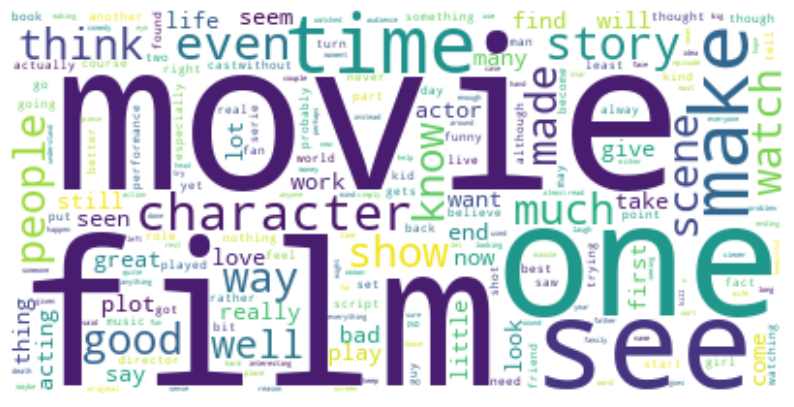

In [14]:
# WordCloud
text = " ".join(review for review in df['html_review'])
wordcloud = WordCloud(stopwords=STOPWORDS, background_color="white").generate(text)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()